In [8]:
using Pkg, Plots
Pkg.activate("..")
Pkg.instantiate()
using Clapeyron, cDFT

[ Info: Precompiling PlotscDFTExt [0a290dff-ae42-5c9f-a62b-7116004d03aa](cache misses: wrong dep version loaded (1), incompatible header (2))
[ Info: Precompiling PlotscDFTExt [0a290dff-ae42-5c9f-a62b-7116004d03aa] (cache misses: wrong dep version loaded (2), incompatible header (4))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
  Activating project at `/nfs/zeal_nas/home_mount/pwalker/Projects/cDFT.jl`


## General set-up
The cDFT and Clapeyron packages are very closely related. Clapeyron provides all the bulk information while cDFT handles all inhomogeneous calculations. The first step in any cDFT calculation is to first define the model species:

In [9]:
model = PCSAFT(["water"])

PCSAFT{BasicIdeal, Float64} with 1 component:
 "water"
Contains parameters: Mw, segment, sigma, epsilon, epsilon_assoc, bondvol

From here, we want to define our system conditions. Here, we will consider the VLE of water at 298.15 K:

In [3]:
T = 298.15
(p, vl, vv) = saturation_pressure(model, T);

With these conditions, we can now define a system structure. To model the VLE system, we will consider a periodic system with a liquid slab surrounded by vapor:

In [12]:
ρl = [1.]/vl
ρv = [1.]/vv

L = cDFT.length_scale(model) # Useful tool to obtain a characteristic length scale for the system, which can be used to non-dimensionalize the problem and choose an appropriate grid size.

structure = TwoPhase1DCart((p, T), ρl, ρv, [-10L,10L], (101,));

With this, we can now fully define our system:

In [13]:
system = DFTSystem(model, structure)

DFTSystem with 1 component:
 model: PCSAFT{BasicIdeal, Float64}("water")
 structure: TwoPhase1DCart
 device: CPU

THis system object contains all the information we might need when running a DFT calculation:
```julia
struct DFTSystem{M<:EoSModel,S<:DFTSpecies,T<:DFTStructure,F,P<:DFTPropagator,O<:DFTOptions,C}
    model::M
    species::S
    structure::T
    fields::F
    propagator::P
    options::O
    chunksize::Val{C}
end
```
Feel free to read the docs to find out more about what is stored in each struct. From here, we can generate an initial density profile that satisfies the system conditions:

In [14]:
ρ = cDFT.initialize_profiles(system);

I've created some convenience functions to quickly visualize the density profiles:

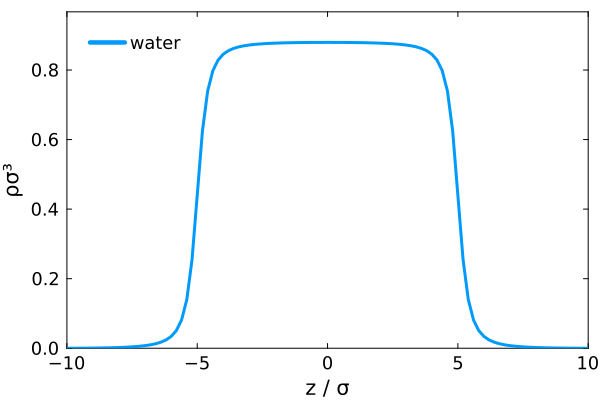

In [15]:
plot(system, ρ)

Note that this profile is just an initial guess and does not correspond to the true equilibrium profile. This profile must be solved for iteratively such that the following equation is satisfied:
$$ \rho(\mathbf{r}) = \rho^b \exp\left(-\beta\frac{\delta F_\mathrm{res}}{\delta \rho(\mathbf{r})}\right)$$

This is achieved using the `converge!(system, ρ)` function:

In [16]:
converge!(system, ρ);

We can see the visual difference in the converged profile:

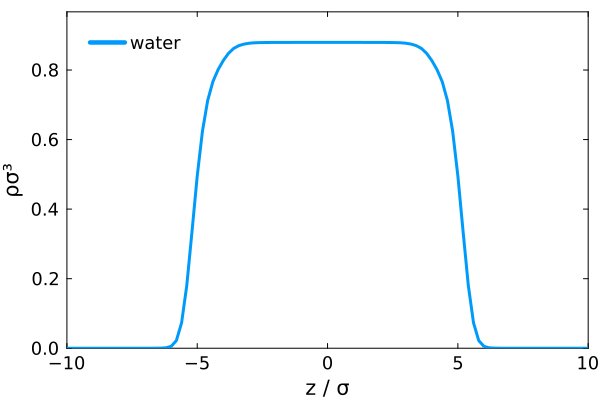

In [17]:
plot(system, ρ)